In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image

def convert_image_to_grayscale(image_path):
    img = Image.open(image_path).convert('L')
    gray_matrix = np.array(img)
    return gray_matrix

def display_image(matrix, title="Image", cmap='gray'):
    plt.imshow(matrix, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis('on')
    plt.show()

def step_1(matrix):
    return int(max([max(row) for row in matrix]))

def calculate_gray_level_frequency(matrix, max_value=255):
    gray_freq = [np.count_nonzero(matrix == i) for i in range(max_value + 1)]
    return gray_freq

def calculate_running_sum(gray_freq):
    running_sum = [0] * len(gray_freq)
    rsum = 0
    for i in range(len(gray_freq)):
        running_sum[i] = gray_freq[i] + rsum
        rsum = running_sum[i]
    return running_sum

def normalize_running_sum(running_sum, total, max_value=255):
    return [math.ceil(running_sum[i] / total * max_value) for i in range(len(running_sum))]

def transform_matrix(matrix, rs_n):
    transformed = np.array([rs_n[value] for value in matrix.flatten()]).reshape(matrix.shape)
    return transformed

def process_image(image_path):
    gray_matrix = convert_image_to_grayscale(image_path)
    display_image(gray_matrix, title="Original Grayscale Image")
    
    max_n = step_1(gray_matrix)
    gray_freq = calculate_gray_level_frequency(gray_matrix, max_value=255)
    print(f"Gray level frequencies: {gray_freq}")
    
    running_sum = calculate_running_sum(gray_freq)
    print(f"Running sum: {running_sum}")
    
    total = gray_matrix.size
    rs_n = normalize_running_sum(running_sum, total, max_value=255)
    print(f"Normalized running sum: {rs_n}")
    
    transformed_matrix = transform_matrix(gray_matrix, rs_n)
    display_image(transformed_matrix, title="Transformed Image")
    
    return transformed_matrix, gray_matrix


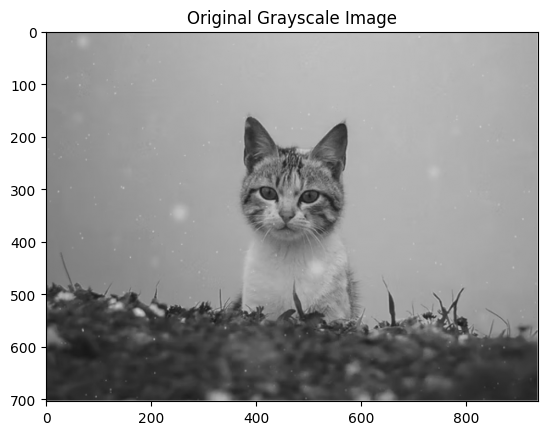

Gray level frequencies: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 6, 10, 18, 89, 101, 107, 128, 250, 186, 165, 195, 276, 272, 286, 333, 469, 551, 723, 953, 1297, 1790, 2188, 2904, 3303, 3559, 4069, 4327, 4411, 4179, 4495, 4522, 4520, 4382, 4265, 4345, 4317, 4424, 4249, 4217, 3925, 3925, 3846, 3526, 3441, 3198, 2949, 2766, 2744, 2664, 2762, 2707, 2354, 2460, 2391, 2240, 2153, 2087, 2051, 1921, 1811, 1741, 1649, 1580, 1499, 1447, 1324, 1176, 1165, 1191, 1216, 1250, 1299, 1088, 1069, 1025, 1102, 1002, 1035, 930, 976, 918, 887, 923, 898, 903, 850, 833, 854, 936, 858, 897, 863, 880, 905, 882, 830, 849, 899, 909, 863, 878, 823, 845, 1122, 1228, 1473, 1624, 1384, 2262, 2231, 2386, 2907, 2445, 3269, 2804, 2645, 2844, 3900, 4186, 3700, 4411, 4567, 4549, 4845, 5610, 5006, 5156, 4714, 5090, 5249, 5156, 4979, 5307, 6603, 5761, 7259, 7805, 6721, 5960, 6094, 7340, 8963, 8322, 10109, 10176, 10981, 11969, 10443, 11916, 13732, 13095, 12038, 11472, 11664, 11970, 11314, 14375, 12783

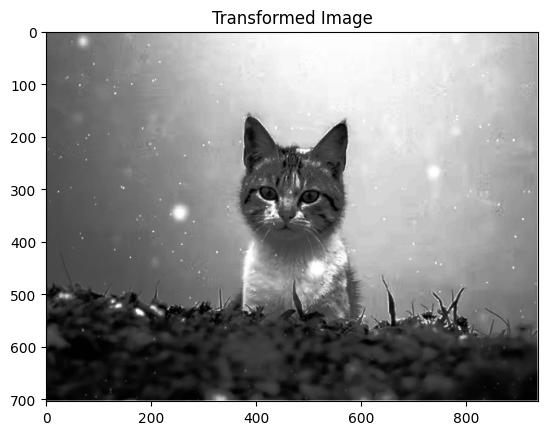

(array([[255, 255, 255, ..., 255, 255, 255],
        [ 99,  99,  99, ..., 176, 176, 255],
        [ 99,  99,  99, ..., 176, 176, 255],
        ...,
        [  5,   5,   3, ...,   6,   7, 199],
        [  5,   4,   3, ...,   7,   7, 199],
        [190, 190, 185, ..., 199, 199, 255]], shape=(704, 937)),
 array([[214, 214, 214, ..., 223, 223, 244],
        [146, 146, 146, ..., 171, 171, 223],
        [146, 146, 146, ..., 171, 171, 223],
        ...,
        [ 42,  42,  40, ...,  43,  44, 176],
        [ 42,  41,  40, ...,  44,  44, 176],
        [174, 174, 173, ..., 176, 176, 229]], shape=(704, 937), dtype=uint8))

In [6]:
process_image('cat2.jpeg')

## side by side